In [ ]:
%load_ext autoreload
%autoreload 2

from spatial_tcr.utils import switch_cwd_to_root

switch_cwd_to_root()

import spatialtools as st

figure_dir = "figures/main-figures/figure_2"
st.utils.setup_plotting(figure_dir)

import os

import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import pandas as pd
import scanpy as sc
import seaborn as sns

from spatial_tcr.colors import colors_new
from spatial_tcr.tcr import get_tcr_genes

# Set the verbosity level
sc.settings.verbosity = 3

In [32]:
path = "data/xenium/processed/04.1-kidney_tcr_tsub_harmonized.h5ad"
adata = sc.read_h5ad(path)
try:
    del adata.uns["cell_type_l2_colors"]
except:
    pass
adata

AnnData object with n_obs × n_vars = 510139 × 480
    obs: 'sample', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'slide', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'n_counts', 'condition', 'cc', 'cell_type_no_tcr', 'cell_type_no_tcr_prob', 'tcell_subtype', 'cell_type_l1', 'cell_type_l2'
    var: 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'
    uns: 'graph', 'log1p'
    obsm: 'cell_type_no_tcr_probs', 'spatial'
    layers: 'counts', 'log1p'

In [33]:
av_genes, bv_genes, dv_genes, gv_genes, tv_genes = get_tcr_genes(adata)

Found 54 TRAV genes, 61 TRBV genes, 3 TRDV genes, 14 TRGV genes


In [34]:
ad_t = adata[adata.obs["cell_type_l1"] == "T"].copy()
ad_t.X = ad_t.layers["counts"].copy()

# remove tv_genes
ad_t = ad_t[:, ~ad_t.var_names.isin(tv_genes)].copy()

sc.pp.normalize_total(ad_t)
sc.pp.log1p(ad_t)
sc.pp.highly_variable_genes(ad_t, n_top_genes=100, batch_key="sample")
ad_t = ad_t[:, ad_t.var["highly_variable"]].copy()

ad_t.X = ad_t.layers["counts"].copy()

sc.pp.normalize_total(ad_t)
sc.pp.log1p(ad_t)

sc.tl.pca(ad_t, n_comps=50)
ad_t.obs["cell_type_l2"].value_counts()

normalizing counts per cell
    finished (0:00:00)
extracting highly variable genes
    finished (0:00:00)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)
normalizing counts per cell
    finished (0:00:00)
computing PCA
    with n_comps=50
    finished (0:00:00)


cell_type_l2
CD4+        9258
CD8+        6509
NKT-like    1842
Tregs       1158
MAIT         820
gdT          446
Name: count, dtype: int64

In [35]:
sc.pp.neighbors(ad_t, use_rep="X_pca", n_neighbors=15)
sc.tl.umap(ad_t)
# sc.pl.umap(
#     ad_t,
#     color="cell_type_l2",
#     # Setting a smaller point size to get prevent overlap
#     size=5,
# )

computing neighbors
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:04)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:16)


In [36]:
def change_label_position(ax, axis="x", scale=0.5):
    if axis == "x":
        label = ax.xaxis.label
    elif axis == "y":
        label = ax.yaxis.label
    else:
        raise ValueError(f"Invalid axis: {axis}")
    x, y = label.get_position()
    transform = label.get_transform()
    if axis == "x":
        label.set_position((x * scale, y))
    elif axis == "y":
        label.set_position((x, y * scale))
    label.set_transform(transform)

In [37]:
color_dict = dict(zip(ad_t.obs["cell_type_l2"].unique(), sns.color_palette("tab10")))
color_dict

{'CD4+': (0.12156862745098039, 0.4666666666666667, 0.7058823529411765),
 'CD8+': (1.0, 0.4980392156862745, 0.054901960784313725),
 'NKT-like': (0.17254901960784313, 0.6274509803921569, 0.17254901960784313),
 'Tregs': (0.8392156862745098, 0.15294117647058825, 0.1568627450980392),
 'gdT': (0.5803921568627451, 0.403921568627451, 0.7411764705882353),
 'MAIT': (0.5490196078431373, 0.33725490196078434, 0.29411764705882354)}

In [38]:
ct_order = ["CD4+", "CD8+", "Tregs", "MAIT", "NKT-like", "gdT"]
ad_t.obs["cell_type_l2"] = pd.Categorical(
    ad_t.obs["cell_type_l2"], categories=ct_order, ordered=True
)

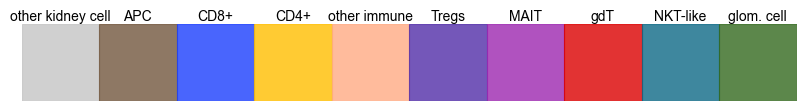

In [39]:
from spatial_tcr.colors import colors_sub

palette = colors_sub

palette_alpha = {
    ct: mcolors.to_rgba(colors_sub[ct], alpha=0.0 if ct == "NA" else 0.8)
    for ct in colors_new.keys()
}
st.pl.utils.plot_palette_dict(palette_alpha)

palette = palette_alpha

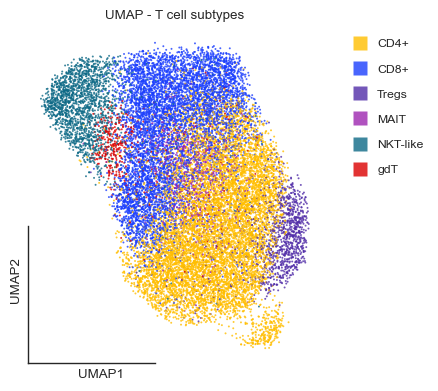

In [40]:
fig, ax = plt.subplots(figsize=(4.5, 4))
sc.pl.umap(
    ad_t,
    color="cell_type_l2",
    show=False,
    ax=ax,
    palette=palette,
    # edgecolor="lightgray",
    # linewidth=0.1,
    size=8,
)
ax.set_title("UMAP - T cell subtypes")
sns.despine(ax=ax)

# shorten the spines
xlim = ax.get_xlim()
ylim = ax.get_ylim()
ax.spines["left"].set_bounds(ylim[0], ylim[1] * 0.5)
ax.spines["bottom"].set_bounds(xlim[0], xlim[1] * 0.5)

change_label_position(ax, axis="x", scale=0.5)
change_label_position(ax, axis="y", scale=0.5)

# Create legend with square patches
from matplotlib.lines import Line2D

legend_handles = [
    Line2D(
        [],
        [],  # no data
        marker="s",  # square marker
        markersize=10,  # edge-to-edge size of the square (pts)
        markerfacecolor=palette[ct],
        markeredgecolor="none",
        linestyle="None",  # hide any line
        label=ct,
    )
    for ct in ct_order
]

ax.legend(
    handles=legend_handles,
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    frameon=False,
    handletextpad=0.4,
    labelspacing=1.2,  # Increase spacing between legend entries
)


plt.tight_layout()
plt.savefig(
    os.path.join(figure_dir, "umap_tcell_subtypes.pdf"), dpi=300, bbox_inches="tight"
)

## compare control vs ANCA composition

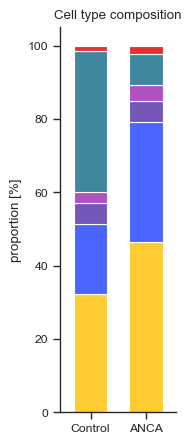

In [41]:
# Create stacked bar plot of cell type proportions by disease
proportions = (
    ad_t.obs.groupby("condition", observed=True)["cell_type_l2"]
    .value_counts(normalize=True)
    .unstack()
)

# reorder
condition_order = ["Control", "ANCA"]
proportions = proportions.reindex(condition_order) * 100

fig, ax = plt.subplots(figsize=(1.5, 5))
proportions.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    color=palette,
    width=0.6,
)

ax.set_title("Cell type composition")
ax.set_xlabel("")
ax.set_ylabel("proportion [%]")
ax.get_legend().remove()
# ax.legend(
#     bbox_to_anchor=(0.5, -0.2),
#     loc="upper center",
#     ncol=7,
#     bbox_transform=ax.transAxes,
#     frameon=False,
# )

sns.despine(ax=ax, right=True, top=True)

# set x-axis labels to ANCA and Control
ax.set_xticklabels(condition_order)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0, ha="center")
# plt.tight_layout()
plt.savefig(
    os.path.join(figure_dir, "tcell_subtype_composition.pdf"),
    dpi=300,
    bbox_inches="tight",
)

## Show marker expression on umap

In [11]:
umap_coords = ad_t.obsm["X_umap"].copy()


ad_t = adata[adata.obs["cell_type_l1"] == "T"].copy()
sc.pp.normalize_total(ad_t)
sc.pp.log1p(ad_t)
ad_t.obsm["X_umap"] = umap_coords

normalizing counts per cell
    finished (0:00:00)


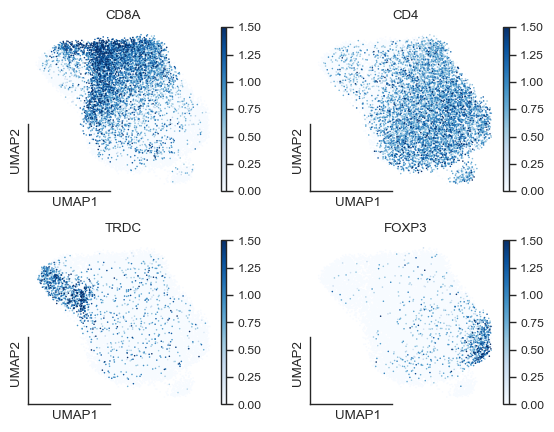

In [12]:
plt.rcParams["figure.figsize"] = (2.3, 2.3)
cmap = "Blues"
# cmap = "Reds"

colors = ["CD8A", "CD4", "TRDC", "FOXP3"]
axs = sc.pl.umap(
    ad_t,
    color=colors,
    # Setting a smaller point size to get prevent overlap
    size=5,
    cmap=cmap,
    vmax=1.5,
    ncols=2,
    hspace=0.3,
    show=False,
)
for ax in axs:
    # despine
    sns.despine(ax=ax)
    # shorten the spines
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    ax.spines["left"].set_bounds(ylim[0], ylim[1] * 0.5)
    ax.spines["bottom"].set_bounds(xlim[0], xlim[1] * 0.5)

    change_label_position(ax, axis="x", scale=0.5)
    change_label_position(ax, axis="y", scale=0.5)

plt.savefig(
    os.path.join(figure_dir, f"tcell_marker_expression_{cmap}.pdf"),
    dpi=300,
    bbox_inches="tight",
)

## Marker expression dotplot / matrix plot with numbers

In [13]:
ct_order = ["CD4+", "CD8+", "Tregs", "MAIT", "NKT-like", "gdT"]
ad_t.obs["cell_type_l2"] = pd.Categorical(
    ad_t.obs["cell_type_l2"], categories=ct_order, ordered=True
)

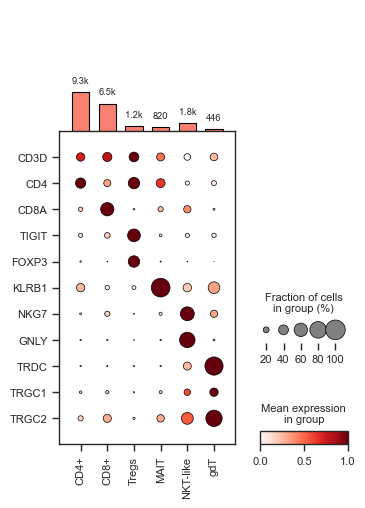

In [14]:
markers = [
    "CD3D",
    "CD4",
    "CD8A",
    "TIGIT",
    "FOXP3",
    "KLRB1",
    "NKG7",
    "GNLY",
    "TRDC",
    "TRGC1",
    "TRGC2",
]
# markers = {
#     "": ["CD4", "CD8A", "KLRB1"],
#     "Tregs": ["TIGIT", "FOXP3"],
#     "gdT": ["TRDC", "TRGC1", "TRGC2"],
# }
# fig = sc.pl.dotplot(ad_t, markers, groupby="cell_type_l2", swap_axes=False, show=False)
dp = sc.pl.dotplot(
    ad_t,
    markers,
    groupby="cell_type_l2",
    return_fig=True,
    standard_scale="var",
    cmap="Reds",
    swap_axes=True,
)
dp.add_totals().style(dot_edge_color="black", dot_edge_lw=0.5)
axs = dp.get_axes()
plt.savefig(
    os.path.join(figure_dir, "tcell_marker_expression_dotplot.pdf"),
    dpi=300,
    bbox_inches="tight",
)
plt.show()